<a href="https://colab.research.google.com/github/popcorn0125/Solar_energy_prediction/blob/main/AI_DX_EDU_%ED%83%9C%EC%96%91%EA%B4%91_%EC%A0%84%EB%A0%A5%EB%9F%89_%EC%98%88%EC%B8%A1_%ED%83%90%EC%83%89%EC%A0%81_%EB%8D%B0%EC%9D%B4%ED%84%B0_%EB%B6%84%EC%84%9D(EDA).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

- 이 과정은 우리가 만든 데이터셋이 '학습하기 좋은 상태'인지 눈으로 검증하는 단계입니다.
- 특히 태양광 발전은 일사량과의 선형 관계(Linearity)가 뚜렷해야 좋은 예측 성능이 나옵니다.

# 4. 탐색적 데이터 분석 (EDA): 데이터 시각화 및 검증

이 단계에서는 병합된 최종 데이터셋(`final_dataset.csv`)을 시각화하여 데이터의 품질과 변수 간의 관계를 파악합니다.

###  주요 점검 항목
1.  **상관관계 분석 (Correlation Heatmap)**:
    * **핵심 질문**: "어떤 날씨 요소가 발전량에 가장 큰 영향을 주는가?"
    * **기대 결과**: `일사량`과 `발전량` 사이에는 매우 강한 양의 상관관계(붉은색, 0.9 이상)가 나타나야 합니다. 반면 `전운량(구름)`이나 `습도`는 음의 상관관계(파란색)를 보일 것입니다.
2.  **산점도 확인 (Scatter Plot)**:
    * `일사량(X)`에 따른 `발전량(Y)`의 분포를 점으로 찍어봅니다.
    * **정상 패턴**: 우상향하는 직선 형태가 나타나야 합니다. 만약 데이터가 너무 퍼져 있거나 이상한 형태라면 전처리가 잘못된 것입니다.
3.  **시간대별 패턴 (Time Series)**:
    * 하루 중 12~13시에 발전량이 피크를 찍고, 밤에는 0이 되는 '종 모양(Bell Curve)' 그래프가 그려지는지 확인합니다.

###  한글 폰트 설정
* 그래프에 한글이 깨지지 않도록 나눔폰트를 설치하고 설정하는 코드가 포함되어 있습니다.

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/n

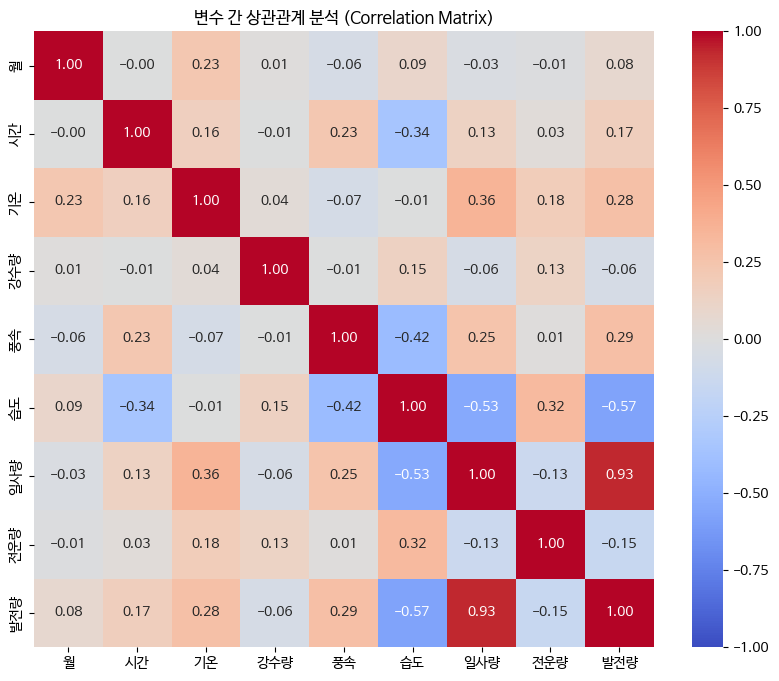


[해석] '발전량'과 가장 상관계수가 높은 변수(진한 빨강)를 찾으세요. 보통 '일사량'이어야 정상입니다.


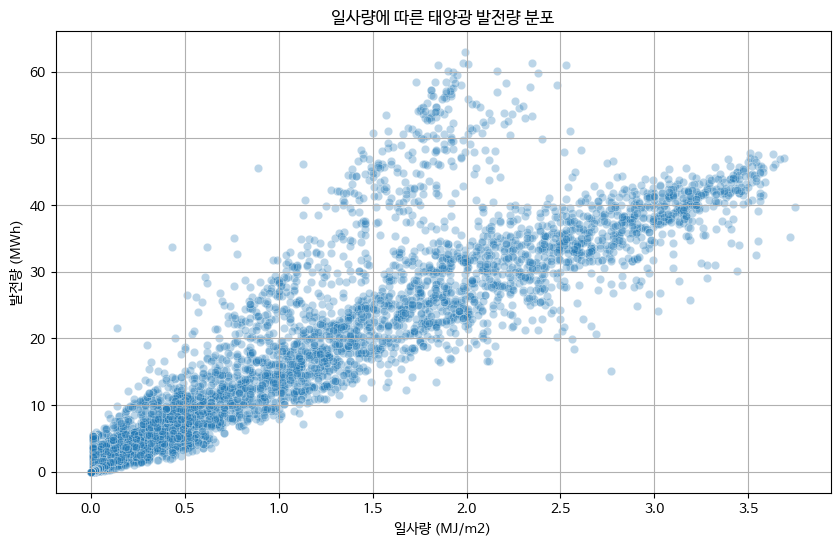


[해석] 점들이 오른쪽 위로 올라가는 직선 형태(우상향)를 그려야 데이터가 정상입니다.


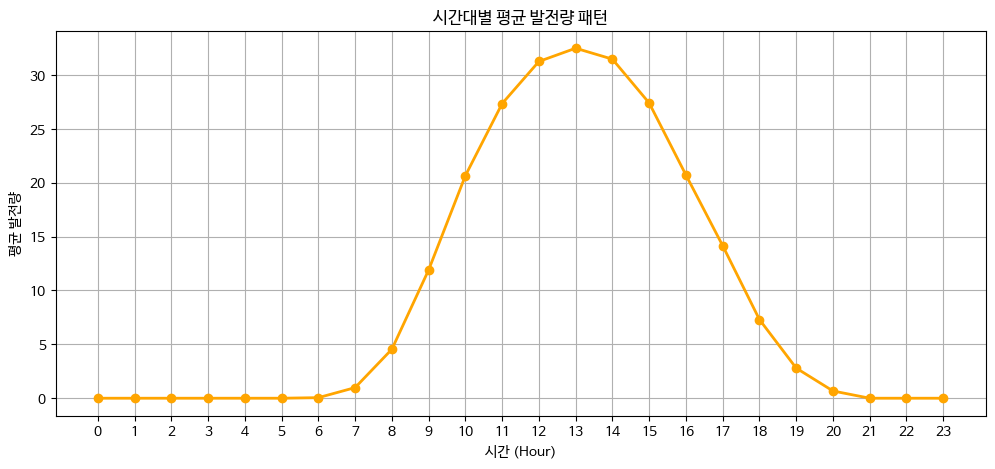


[해석] 12~13시에 가장 높고, 밤에는 0인 '종 모양' 그래프인지 확인하세요.


In [ ]:
# [1] 한글 폰트 설치 및 설정 (Colab 전용)
# 실행 후 '런타임 다시 시작'을 해야 할 수도 있습니다.
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 폰트 설정
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

# [2] 데이터 로드
filename = '/content/drive/MyDrive/Colab Notebooks/solar_energy_prediction/final_dataset_for_AI.csv'
try:
    df = pd.read_csv(filename)
    print(f"'{filename}' 로드 완료: 총 {len(df)}개 데이터")
except FileNotFoundError:
    print(f"[오류] '{filename}' 파일이 없습니다. 이전 단계(병합)를 먼저 실행해주세요.")
    # 코드를 중단하지 않고 데모를 위해 빈 DataFrame 생성 방지

# [3] 상관관계 히트맵 (Heatmap)
plt.figure(figsize=(10, 8))
# 수치형 컬럼만 선택하여 상관계수 계산
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('변수 간 상관관계 분석 (Correlation Matrix)')
plt.show()

print("\n[해석] '발전량'과 가장 상관계수가 높은 변수(진한 빨강)를 찾으세요. 보통 '일사량'이어야 정상입니다.")

# [4] 산점도 (Scatter Plot): 일사량 vs 발전량
plt.figure(figsize=(10, 6))
sns.scatterplot(x='일사량', y='발전량', data=df, alpha=0.3)
plt.title('일사량에 따른 태양광 발전량 분포')
plt.xlabel('일사량 (MJ/m2)')
plt.ylabel('발전량 (MWh)')
plt.grid(True)
plt.show()

print("\n[해석] 점들이 오른쪽 위로 올라가는 직선 형태(우상향)를 그려야 데이터가 정상입니다.")

# [5] 시간대별 평균 발전량 패턴 (Line Plot)
plt.figure(figsize=(12, 5))
# 시간별로 그룹화하여 평균 계산
hourly_mean = df.groupby('시간')['발전량'].mean()

hourly_mean.plot(kind='line', marker='o', color='orange', linewidth=2)
plt.title('시간대별 평균 발전량 패턴')
plt.xlabel('시간 (Hour)')
plt.ylabel('평균 발전량')
plt.xticks(range(0, 24))
plt.grid(True)
plt.show()

print("\n[해석] 12~13시에 가장 높고, 밤에는 0인 '종 모양' 그래프인지 확인하세요.")